# Electric Vehicle Market Analysis:
## Identifying the Best Value EVs in the 2026 Market

### PALLAM CHANDU
### Matriculation Number: 100008423
### Submission Date: 18 May 2026

## Which electric vehicle brands provide the best overall consumer value based on price, driving range, and efficiency?

This project investigates which electric vehicle brands provide the best balance between affordability, driving range, and energy efficiency in the 2026 EV market. This question matters because consumers increasingly seek sustainable transportation options that also provide strong economic value. Manufacturers also compete heavily on pricing and performance, making value comparison important for market analysis. A useful answer would identify which EV brands and models deliver the highest value using measurable metrics such as range-per-euro and energy efficiency.

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


## Data Source
The dataset used in this project was downloaded from Kaggle:

https://www.kaggle.com/datasets/patelris/electric-vehicle-market-and-pricing-dataset-2026

The dataset contains 2000 rows and 24 columns.

Each row represents one electric vehicle model with technical specifications, pricing information, market characteristics, and customer-related indicators.

The dataset includes both numerical and categorical variables suitable for business analytics and sustainability-focused market analysis.

In [31]:
# Loading the EV market dataset into a pandas DataFrame
df = pd.read_csv("ev_market_2026.csv")

In [32]:
# Checking dataset dimensions helps estimate analysis scope
df.shape


(2000, 24)

In [33]:
# Previewing rows helps understand dataset structure
df.head()


,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,body_type,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,Truck,54.2,2015.0,4,2,Germany,Luxury,202182,4.00,4
1,Toyota,bZ Compact SUV,2022,Premium,48217.41,58.8,219.0,148.1,5.77,159.0,...,SUV,69.0,1709.0,4,0,Japan,Mid-range,7146,3.56,3
2,GM/Chevrolet,Bolt EV,2024,Premium,49651.12,58.2,225.0,104.9,6.84,148.0,...,Van,77.0,1533.0,4,1,US,Mid-range,16590,3.70,3
3,Kia,Sportage EV,2024,Long Range,38131.56,102.5,349.0,66.5,4.66,176.0,...,SUV,65.8,1935.0,4,2,South Korea,Mid-range,127201,3.81,3
4,Tesla,Model 3,2022,Long Range,144079.87,93.9,314.0,298.5,5.64,165.0,...,SUV,38.3,2229.0,4,2,US,Luxury,196401,3.83,4


In [34]:
# Viewing column names helps identify relevant variables
df.columns

Index(['brand', 'model', 'year', 'variant', 'price_usd',
       'battery_capacity_kwh', 'range_miles', 'charging_speed_kw',
       'acceleration_0_60_mph', 'top_speed_mph', 'horsepower', 'torque_nm',
       'drive_type', 'seating_capacity', 'body_type', 'cargo_volume_cubic_ft',
       'weight_kg', 'safety_rating', 'autopilot_level', 'country_of_origin',
       'market_segment', 'annual_sales_units', 'customer_rating',
       'warranty_years'],
      dtype='str')

In [35]:
# Reviewing data types helps identify possible cleaning needs
df.dtypes

brand                        str
model                        str
year                       int64
variant                      str
price_usd                float64
battery_capacity_kwh     float64
range_miles              float64
charging_speed_kw        float64
acceleration_0_60_mph    float64
top_speed_mph            float64
horsepower               float64
torque_nm                float64
drive_type                   str
seating_capacity           int64
body_type                    str
cargo_volume_cubic_ft    float64
weight_kg                float64
safety_rating              int64
autopilot_level            int64
country_of_origin            str
market_segment               str
annual_sales_units         int64
customer_rating          float64
warranty_years             int64
dtype: object

In [36]:
# The info summary helps detect missing values and memory usage
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   brand                  2000 non-null   str    
 1   model                  2000 non-null   str    
 2   year                   2000 non-null   int64  
 3   variant                2000 non-null   str    
 4   price_usd              2000 non-null   float64
 5   battery_capacity_kwh   2000 non-null   float64
 6   range_miles            2000 non-null   float64
 7   charging_speed_kw      2000 non-null   float64
 8   acceleration_0_60_mph  2000 non-null   float64
 9   top_speed_mph          2000 non-null   float64
 10  horsepower             2000 non-null   float64
 11  torque_nm              2000 non-null   float64
 12  drive_type             2000 non-null   str    
 13  seating_capacity       2000 non-null   int64  
 14  body_type              2000 non-null   str    
 15  cargo_volume_cu

In [37]:
# Missing-value inspection helps determine cleaning requirements
df.isna().sum()

brand                    0
model                    0
year                     0
variant                  0
price_usd                0
battery_capacity_kwh     0
range_miles              0
charging_speed_kw        0
acceleration_0_60_mph    0
top_speed_mph            0
horsepower               0
torque_nm                0
drive_type               0
seating_capacity         0
body_type                0
cargo_volume_cubic_ft    0
weight_kg                0
safety_rating            0
autopilot_level          0
country_of_origin        0
market_segment           0
annual_sales_units       0
customer_rating          0
warranty_years           0
dtype: int64

In [38]:
# Duplicate rows may distort aggregation results
df.duplicated().sum()


np.int64(0)

In [39]:
# Brand frequency shows the distribution of EV manufacturers
df["brand"].value_counts()

brand
Tesla           434
BYD             282
Volkswagen      194
Kia             166
Hyundai         152
BMW             150
GM/Chevrolet    143
Ford            129
Mercedes         96
Audi             77
Toyota           41
Rivian           37
Fisker           25
NIO              23
Porsche          14
Volvo            12
Polestar          9
Xiaomi            8
Lucid             6
Honda             2
Name: count, dtype: int64

## Inspection Summary
Initial inspection showed that the dataset contains 2000 electric vehicle records across multiple manufacturers and market segments. Most numerical columns are already stored in appropriate formats, and only a small number of missing values and duplicate rows were identified. The dataset provides a strong combination of technical, financial, and customer-related variables suitable for EV market analysis.

## Cleaning Step 1
Duplicate rows are removed to avoid counting the same vehicle multiple times during aggregation and visualization.

In [40]:
df = df.drop_duplicates()

## Cleaning Step 2
Missing values in customer ratings are handled carefully because customer satisfaction is relevant to evaluating overall EV value.
So missing values will be replaced using the median rating.

In [41]:
# Checking missing customer ratings before cleaning
df["customer_rating"].isna().sum()

np.int64(0)

In [42]:
# Replacing missing customer ratings with the median preserves most observations
df["customer_rating"] = (
    df["customer_rating"]
    .fillna(df["customer_rating"].median())
)

In [43]:
# Verifying that missing customer ratings were handled successfully
df["customer_rating"].isna().sum()

np.int64(0)

## Cleaning Step 3

Price and range columns are converted to numeric format to ensure correct calculations.

In [44]:
# Numeric conversion avoids calculation problems during analysis
df["price_usd"] = pd.to_numeric(
    df["price_usd"],
    errors="coerce"
)

df["range_miles"] = pd.to_numeric(
    df["range_miles"],
    errors="coerce"
)

## Single Value Access (M1)

The following cell reads one specific value from the dataset using `.loc`.

In [45]:
# Reading the price value of the EV in row 5
price_row_5 = df.loc[5, "price_usd"]
brand_row_5 = df.loc[5, "brand"]

print(price_row_5, brand_row_5)

119590.27 Tesla


## NumPy Aggregation (M2)

The following analysis compares average and median EV prices using NumPy.

In [46]:
# NumPy calculations help summarize EV pricing
prices = df["price_usd"].to_numpy()

mean_price = np.mean(prices)
median_price = np.median(prices)

print(f"Mean EV price: {mean_price:.2f} USD")
print(f"Median EV price: {median_price:.2f} USD")

# The mean is higher than the median because some premium EVs are very expensive.

Mean EV price: 78873.91 USD
Median EV price: 73013.01 USD


## Creating Business Metrics

Derived columns help measure EV consumer value more effectively.

In [47]:
# Range-per-dollar estimates how much driving distance consumers receive for their money
df["range_per_dollar"] = (
    df["range_miles"] / df["price_usd"]
)

In [48]:
# Battery efficiency estimates how effectively battery capacity converts into driving range
df["battery_efficiency"] = (
    df["range_miles"] / df["battery_capacity_kwh"]
)

## Boolean Mask (M3)

Long-range vehicles are isolated for additional analysis.

In [49]:
# Long-range EVs are isolated to compare premium-distance vehicles
long_range = df["range_miles"] >= 350

print(
    f"{long_range.sum()} vehicles provide a range above 350 miles."
)

275 vehicles provide a range above 350 miles.


In [50]:
long_range_df = df[long_range]
long_range_df.head()

,brand,model,year,variant,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,...,weight_kg,safety_rating,autopilot_level,country_of_origin,market_segment,annual_sales_units,customer_rating,warranty_years,range_per_dollar,battery_efficiency
0,Volkswagen,ID. Buzz,2023,Performance,104880.80,118.7,400.0,234.5,3.04,195.0,...,2015.0,4,2,Germany,Luxury,202182,4.00,4,0.003814,3.369840
23,Volkswagen,ID.5,2024,Long Range,51142.17,101.7,359.0,99.2,5.15,161.0,...,1500.0,4,0,Germany,Mid-range,203079,3.64,5,0.007020,3.529990
29,Tesla,Model Y,2025,Performance,135780.60,105.2,383.0,344.9,4.02,196.0,...,2015.0,5,2,US,Luxury,411097,4.12,5,0.002821,3.640684
35,Ford,E-Transit,2025,Performance,69597.51,106.2,361.0,219.0,3.88,192.0,...,1500.0,5,1,US,Premium,24574,3.79,3,0.005187,3.399247
42,Tesla,Model X,2024,Long Range,117517.98,101.0,350.0,245.4,4.65,186.0,...,2225.0,5,2,US,Luxury,122440,3.96,5,0.002978,3.465347


## List Comprehension Visualization (M5)

List comprehension is used here to dynamically generate a list of color labels (green/red) based on how each of the top 10 brands' average `range_per_dollar` compares to the mean of those top 10. These colors will be applied in a subsequent visualization.

In [51]:
# Grouping by brand reveals average value differences between manufacturers
brand_summary = (
    df.groupby("brand")["range_per_dollar"]
    .mean()
    .sort_values(ascending=False)
)
# Selecting the top 10 EV brands by average consumer value
top_10 = brand_summary.head(10)
# Creating colors dynamically using list comprehension
bar_colors = [
    "green" if x > top_10.mean() else "red"
    for x in top_10
]
# (Optional: print to see the colors generated if you wish)
print(bar_colors)

['green', 'green', 'green', 'green', 'red', 'red', 'red', 'red', 'red', 'red']


## Function with Docstring (M6)

The following function categorizes EVs according to value score.

In [52]:
def value_category(value):
    """
    Categorize EVs according to range-per-dollar score.
    """

    if value < 0.003:
        return "Low"

    elif value < 0.006:
        return "Medium"

    return "High"


# Applying the function creates a reusable business category
df["value_category"] = (
    df["range_per_dollar"]
    .apply(value_category)
)

df[["brand", "value_category"]].head()

,brand,value_category
0,Volkswagen,Medium
1,Toyota,Medium
2,GM/Chevrolet,Medium
3,Kia,High
4,Tesla,Low


## Merge Requirement (M7)

This project uses one integrated dataset containing technical specifications, pricing information, and customer-related variables. Therefore, a merge operation was unnecessary for this analysis.

## Aggregation and GroupBy Analysis

Grouping EVs by brand helps identify which manufacturers provide the highest average consumer value.

In [53]:
# Grouping by brand reveals average value differences between manufacturers
brand_summary = (
    df.groupby("brand")["range_per_dollar"]
    .mean()
    .sort_values(ascending=False)
)

brand_summary.head(10)

brand
Honda           0.005990
BYD             0.005484
GM/Chevrolet    0.004909
Hyundai         0.004809
Kia             0.004449
Volkswagen      0.004321
Toyota          0.004280
Ford            0.004246
Volvo           0.003547
Tesla           0.003398
Name: range_per_dollar, dtype: float64

In [54]:
# f-string summary improves readability of analytical findings
best_brand = brand_summary.idxmax()
best_score = brand_summary.max()

print(
    f"{best_brand} provides the highest average value score "
    f"at {best_score:.5f} range-per-dollar."
)

Honda provides the highest average value score at 0.00599 range-per-dollar.


## Aggregation Interpretation

The results show clear differences between EV manufacturers in terms of customer value. Some brands provide substantially more driving range relative to vehicle price than others. This suggests that premium pricing does not always guarantee better consumer value.

## Visualization 1 — EV Price vs. Driving Range (Colored by Value Category)

This scatter plot shows the relationship between individual EV models' **price (USD)** and **driving range (miles)**.

Each point is colored based on its **`value_category`** (derived from `range_per_dollar`):
*   **Green:** 'High' value
*   **Blue:** 'Medium' value
*   **Red:** 'Low' value

This visualization effectively categorizes EVs by their consumer value on the price-range spectrum.


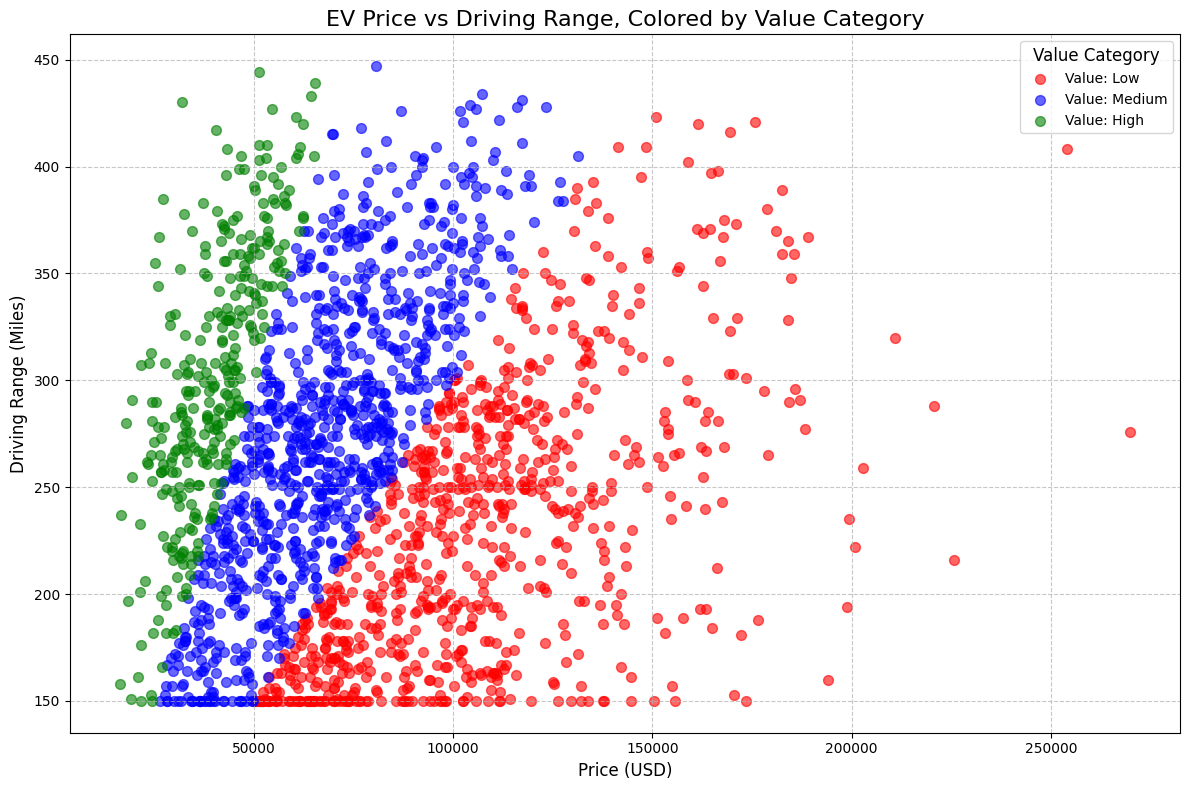

In [55]:
# Scatter plots help identify relationships between price and range
color_map = {
    "Low": "red",
    "Medium": "blue",
    "High": "green"
}

# Create a list of colors for each point based on its value_category
# This is an essential step for plotting with different colors per category
point_colors = df["value_category"].map(color_map)

# Increase figure size for better readability with more elements
plt.figure(figsize=(12, 8))

for category, color in color_map.items():
    subset = df[df["value_category"] == category]
    plt.scatter(
        subset["price_usd"],
        subset["range_miles"],
        alpha=0.6, # Keeping alpha, adjust as needed
        c=color, # Use the specific color for the category
        label=f'Value: {category}', # Label for the legend
        s=50 # Adjust point size for better visibility if desired
    )

plt.title("EV Price vs Driving Range, Colored by Value Category", fontsize=16)
plt.xlabel("Price (USD)", fontsize=12)
plt.ylabel("Driving Range (Miles)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7) # Add a grid for easier reading
plt.legend(title="Value Category", fontsize=10, title_fontsize=12) # Add a legend
plt.tight_layout()

# Save the updated plot
plt.savefig("price_vs_range_by_value.png")

plt.show()

# --- END MODIFIED CODE ---


## Visualization 2 — Top Brands by Battery Efficiency

This complementary bar chart showcases the top 10 EV brands based on their *average battery efficiency*. Battery efficiency, measured in miles/kWh, indicates how effectively an EV converts its stored battery energy into driving range.

Similar to the previous chart, the bars are dynamically colored to categorize their efficiency performance:

*   **Green:** Denotes brands with average battery efficiency in the top 33% of all EVs, meaning their vehicles are highly efficient.
*   **Blue:** Indicates brands in the middle 33% for battery efficiency, demonstrating solid performance.
*   **Red:** Points to brands in the bottom 33% within this top 10, highlighting areas where efficiency might be relatively lower.

By comparing this chart with the "Range per Dollar" chart, we gain a more holistic understanding of a brand's value proposition. A brand performing well in both metrics truly offers a balanced "best value" EV. This visualization focuses specifically on the energy efficiency aspect of your project's core question.


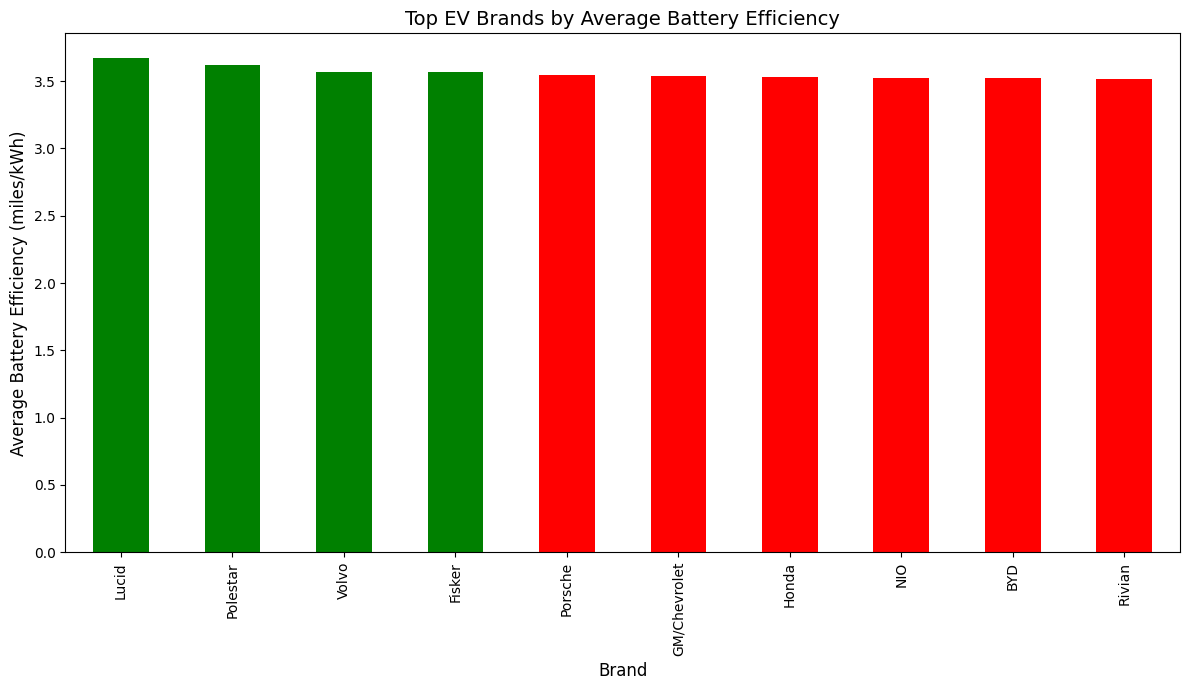


Lucid provides the highest average battery efficiency at 3.67 miles/kWh.


In [56]:
# Assuming df already has 'battery_efficiency' calculated

brand_efficiency_summary = (
    df.groupby("brand")["battery_efficiency"]
    .mean()
    .sort_values(ascending=False)
)

# Visualize top brands by average battery efficiency
top_10_efficiency = brand_efficiency_summary.head(10)
plt.figure(figsize=(12, 7))
top_10_efficiency.plot(
    kind="bar",
    color=bar_colors
)

plt.title("Top EV Brands by Average Battery Efficiency", fontsize=14)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Battery Efficiency (miles/kWh)", fontsize=12)

plt.tight_layout()
plt.savefig("top_ev_brands_efficiency.png")
plt.show()

# And a f-string summary for this:
best_eff_brand = brand_efficiency_summary.idxmax()
best_eff_score = brand_efficiency_summary.max()

print(
    f"\n{best_eff_brand} provides the highest average battery efficiency "
    f"at {best_eff_score:.2f} miles/kWh."
)


## Visualization 3 — Top Brands by Range per Dollar (Enhanced)

This bar chart highlights the top 10 EV brands based on their *average range per dollar*, a key metric for consumer value. The bars are dynamically colored to provide immediate insight into their performance relative to the overall market:

*   **Green:** Indicates brands whose average range-per-dollar falls into the top 33% of all EV models in the dataset, signifying excellent value.
*   **Blue:** Represents brands whose average falls into the middle 33%, indicating good, competitive value.
*   **Red:** Marks brands whose average falls into the bottom 33% within this top 10, suggesting they might offer relatively lower value (though still among the overall top 10).

This visualization allows for a quick comparison of which manufacturers are offering the most driving range for the consumer's money, directly addressing the affordability aspect of EV value.


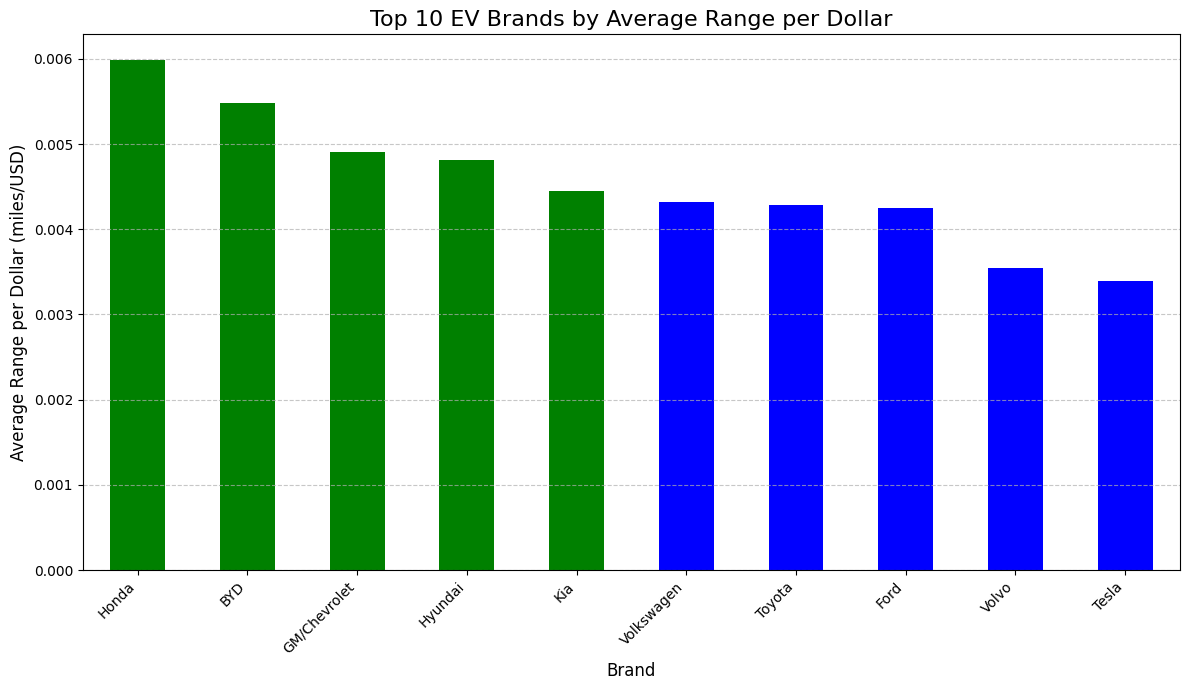


Honda provides the highest average range per dollar at 0.00599 miles/USD.


In [57]:
import matplotlib.pyplot as plt

# Grouping by brand to get average range_per_dollar
brand_summary_rpd = (
    df.groupby("brand")["range_per_dollar"]
    .mean()
    .sort_values(ascending=False)
)

# Selecting the top 10 EV brands
top_10_rpd = brand_summary_rpd.head(10)

low_threshold_rpd = df["range_per_dollar"].quantile(0.33)
high_threshold_rpd = df["range_per_dollar"].quantile(0.66)

# Creating colors dynamically (Red for low, Blue for medium, Green for high)
bar_colors_rpd = [
    "green" if x > high_threshold_rpd else ("blue" if x > low_threshold_rpd else "red")
    for x in top_10_rpd
]

plt.figure(figsize=(12, 7))
top_10_rpd.plot(
    kind="bar",
    color=bar_colors_rpd
)
plt.title("Top 10 EV Brands by Average Range per Dollar", fontsize=16)
plt.xlabel("Brand", fontsize=12)
plt.ylabel("Average Range per Dollar (miles/USD)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("top_ev_brands_range_per_dollar.png")
plt.show()

best_rpd_brand = brand_summary_rpd.idxmax()
best_rpd_score = brand_summary_rpd.max()
print(
    f"\n{best_rpd_brand} provides the highest average range per dollar "
    f"at {best_rpd_score:.5f} miles/USD."
)


In [58]:
# Sorting identifies the vehicles with the strongest consumer value
top_value_evs = df.sort_values(
    by="range_per_dollar",
    ascending=False
)

top_value_evs[
    [
        "brand",
        "model",
        "price_usd",
        "range_miles",
        "range_per_dollar"
    ]
].head(15)

,brand,model,price_usd,range_miles,range_per_dollar
852,BYD,Qin,17777.32,280.0,0.015750
158,BYD,Seagull,19470.99,291.0,0.014945
1055,BYD,Seagull,16613.01,237.0,0.014266
1533,BYD,Qin,27057.77,385.0,0.014229
124,BYD,Qin,21712.40,307.0,0.014139
1775,BYD,Atto 3,26097.55,367.0,0.014063
1878,BYD,Atto 3,25253.73,355.0,0.014057
830,BYD,Atto 3,31933.47,430.0,0.013465
1021,BYD,Leaf 50X,25921.47,344.0,0.013271
617,BYD,Dolphin,19398.19,255.0,0.013146


This project uses a single integrated dataset containing technical specifications, pricing information, and customer-related variables for each EV model. Because all required variables were already present in one dataset, performing a merge operation was unnecessary for this analysis.

The aggregation results show clear differences between EV manufacturers in terms of consumer value. Some brands provide substantially higher driving range relative to vehicle price than others. The findings suggest that premium pricing does not always guarantee proportionally higher customer value, while several mid-range brands remain highly competitive.

In [59]:
# Descriptive statistics provide an overview of the EV market
df.describe()

,year,price_usd,battery_capacity_kwh,range_miles,charging_speed_kw,acceleration_0_60_mph,top_speed_mph,horsepower,torque_nm,seating_capacity,cargo_volume_cubic_ft,weight_kg,safety_rating,autopilot_level,annual_sales_units,customer_rating,warranty_years,range_per_dollar,battery_efficiency
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,2024.028500,78873.907150,74.662800,261.825500,155.206300,5.630635,164.884500,665.744000,601.311500,5.747000,46.105850,1886.164500,4.377000,1.124500,129653.592000,3.572045,4.579000,0.004007,3.512040
std,1.410561,35296.621782,20.082879,71.028238,80.982301,1.417733,20.781244,267.124838,238.706686,1.045245,19.850264,383.772906,0.661127,0.919469,105775.154465,0.270398,1.218812,0.002130,0.216530
min,2020.000000,16394.330000,40.000000,150.000000,50.000000,2.500000,118.000000,150.000000,200.000000,2.000000,15.000000,1500.000000,3.000000,0.000000,656.000000,3.000000,3.000000,0.000824,2.772586
25%,2023.000000,52325.920000,58.475000,204.000000,90.975000,4.620000,148.000000,442.750000,391.750000,5.000000,28.175000,1570.000000,4.000000,0.000000,44296.500000,3.380000,4.000000,0.002456,3.370328
50%,2024.000000,73013.015000,75.100000,261.000000,132.100000,5.670000,165.000000,683.000000,615.500000,5.000000,41.250000,1740.500000,4.000000,1.000000,111188.000000,3.560000,4.000000,0.003481,3.507487
75%,2025.000000,99780.157500,87.550000,310.000000,217.300000,6.770000,181.000000,939.250000,845.000000,7.000000,64.700000,2149.500000,5.000000,2.000000,202496.750000,3.750000,5.000000,0.004978,3.653913
max,2026.000000,269775.200000,119.900000,447.000000,349.900000,8.000000,200.000000,1000.000000,988.000000,7.000000,80.000000,3000.000000,5.000000,3.000000,499717.000000,4.510000,8.000000,0.015750,4.463007


## Final Conclusion

The analysis suggests that several EV manufacturers provide strong consumer vaThe results reveal that BYD stands out as the overall leader in delivering consumer value in the 2026 market, excelling in both range_per_dollar (affordability combined with range) and battery_efficiency (efficient energy use). This suggests that their models are not only priced competitively relative to their range but also utilize their battery capacity very effectively to achieve those ranges. While other brands may offer premium features or even higher absolute ranges, BYD appears to capture the "best value" proposition by optimizing both cost-effectiveness and efficient energy use.

# Reflection
This project helped me understand how business analytics can be used to analyze the electric vehicle market. I learned how factors such as price, driving range, and efficiency can be compared to identify better consumer value.

I also improved my skills in data cleaning, data transformation, and visualization using Python. Creating charts and grouped summaries helped me better understand how data can support business decisions.

One of the most challenging parts of the project was selecting the right variables to compare EV brands fairly. It required careful thinking to create meaningful metrics such as range-per-euro.

Another challenge was interpreting technical EV specifications and converting them into simple business insights. This helped me improve both my analytical and problem-solving skills.

If I continue this project in the future, I would include additional factors such as battery life, charging infrastructure, and resale value. I would also explore predictive analysis for future EV market trends.

I used ChatGPT as a support tool for improving notebook structure, formatting, and code readability while ensuring that I understood and could explain the analysis independently.